#EDA_TATA Steel Machine Failure Prediction


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member -** - Manjushree T R


# **Project Summary -**

Provide your GitHub Link here.

TATA Steel Machine Failure Prediction

TATA Steel, a major global steel manufacturer, faces considerable issues in maintaining the efficiency of its heavy machinery. Machine failures in steel factories can result in significant financial losses, production downtime, and safety concerns. To address these difficulties, TATA Steel created a machine failure prediction system based on data analytics and machine learning approaches.


Problem Statement
Traditional maintenance solutions, such as reactive (repairs after failure) and preventive (planned maintenance), are inefficient and costly. TATA Steel sought a data-driven approach to detect breakdowns before they occurred, allowing for preventive maintenance.

Solution Approach
TATA Steel predicted failures using an advanced analytics-based method that used historical data, sensor readings, and machine learning models. The important steps in the solution were:

Data Collection, Preprocessing, Data Preprocessing, Cleaning and handling missing values, Model Development, Model Evaluation and Deployment, learning predictions with alert mechanisms.

Benefits and Impact

The machine failure prediction system at TATA Steel has led to significant operational improvements, including:
Reduced Downtime
Cost Savings
Improved Safety
Enhanced Productivity

Conclusion
TATA Steel's machine failure prediction initiative is a successful example of how data analytics can transform industrial operations.

# **GitHub Link -**

# **Problem Statement**


TATA Steel operates in demanding industrial environments, making equipment maintenance a crucial challenge. This analysis, supported by visualizations, helps identify where issues are occurring, enabling better problem detection and resolution.

#### **Define Your Business Objective?**

The main purpose of this analysis is to enhance equipment maintenance efficiency at TATA Steel by identifying failure patterns and key factors affecting machine performance. By leveraging data analysis and visualizations, the goal is to:

Detect Failure Trends,
Optimize Maintenance Strategies,
Reduce Downtime ,
Improve Overall Efficiency,
This analysis will help TATA Steel reduce maintenance costs, improve machine reliability, and ensure smooth production operations.

# EDA Analysis


## ***1. Know Your Data***

#### Import Libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
from wordcloud import WordCloud

### Preprocessing
#### Exploring data

In [75]:
df= pd.read_csv(r'/content/test (1).csv')

In [76]:
df.shape

(90954, 13)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90954 entries, 0 to 90953
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        90954 non-null  int64  
 1   Product ID                90954 non-null  object 
 2   Type                      90954 non-null  object 
 3   Air temperature [K]       90954 non-null  float64
 4   Process temperature [K]   90954 non-null  float64
 5   Rotational speed [rpm]    90954 non-null  int64  
 6   Torque [Nm]               90954 non-null  float64
 7   Tool wear [min]           90954 non-null  int64  
 8   Tool Wear Failure         90954 non-null  int64  
 9   Heat Dissipation Failure  90954 non-null  int64  
 10  Power Failure             90954 non-null  int64  
 11  Overstrain Failure        90954 non-null  int64  
 12  Random Failures           90954 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 9.0+ MB


In [78]:
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


#### Duplicate Values

In [79]:
df.id.nunique()

90954

In [80]:
df["Product ID"].nunique()

9909

Since the ID field contains no duplicates, it can be considered the primary key.









#### Missing Values/Null Values

In [81]:
df.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Tool Wear Failure,0
Heat Dissipation Failure,0


We have no variables with missing values.

### What did you know about your dataset?
There are multiple records for each product, but the Product ID is unique for each item and can be treated as the primary key for the dataset. This ensures that each product can be distinctly identified and tracked, even if there are multiple records associated with it over time.

## ***2. Understanding Your Variables***

####Dataset Columns

In [82]:
print(df.columns)


Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Tool Wear Failure', 'Heat Dissipation Failure',
       'Power Failure', 'Overstrain Failure', 'Random Failures'],
      dtype='object')


In [83]:
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [84]:
df.tail()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures
90949,227378,L51130,L,302.3,311.4,1484,40.4,15,0,0,0,0,0
90950,227379,L47783,L,297.9,309.8,1542,33.8,31,0,0,0,0,0
90951,227380,L48097,L,295.6,306.2,1501,41.4,187,0,0,0,0,0
90952,227381,L48969,L,298.1,307.8,1534,40.3,69,0,0,0,0,0
90953,227382,L52525,L,303.5,312.8,1534,36.1,92,0,0,0,0,0


#### Dataset Describe

In [85]:
df.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures
count,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.00000,90954.000000
mean,181905.500000,299.859493,309.939375,1520.528179,40.335191,104.293962,0.001473,0.005343,0.002353,0.00387,0.002309
std,26256.302529,1.857562,1.385296,139.970419,8.504683,63.871092,0.038355,0.072903,0.048449,0.06209,0.047995
min,136429.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,159167.250000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,181905.500000,300.000000,310.000000,1493.000000,40.500000,106.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,204643.750000,301.200000,310.900000,1579.000000,46.200000,158.000000,0.000000,0.000000,0.000000,0.00000,0.000000
max,227382.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.00000,1.000000


### Variables Description

## 3. ***Data Wrangling***


In [86]:
print(df.dtypes)

id                            int64
Product ID                   object
Type                         object
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Tool Wear Failure             int64
Heat Dissipation Failure      int64
Power Failure                 int64
Overstrain Failure            int64
Random Failures               int64
dtype: object


All columns have the correct data types, and there are no missing values, as each column contains 90,954 entries without any null values. The ID column has been considered as the primary key, ensuring uniqueness with no duplicate values.

Creating new Columns

In [87]:
df['Total Failures'] = df[['Tool Wear Failure', 'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure', 'Random Failures']].apply(lambda row: 1 if row.sum() > 0 else 0, axis=1)

print(df)

           id Product ID Type  Air temperature [K]  Process temperature [K]  \
0      136429     L50896    L                302.3                    311.5   
1      136430     L53866    L                301.7                    311.0   
2      136431     L50498    L                301.3                    310.4   
3      136432     M21232    M                300.1                    309.6   
4      136433     M19751    M                303.4                    312.3   
...       ...        ...  ...                  ...                      ...   
90949  227378     L51130    L                302.3                    311.4   
90950  227379     L47783    L                297.9                    309.8   
90951  227380     L48097    L                295.6                    306.2   
90952  227381     L48969    L                298.1                    307.8   
90953  227382     L52525    L                303.5                    312.8   

       Rotational speed [rpm]  Torque [Nm]  Tool we

In [88]:
df['Total Failures']

,Total Failures
0,0
1,0
2,0
3,0
4,0
...,...
90949,0
90950,0
90951,0
90952,0


In [89]:
totalfailures_counts = df['Total Failures'].value_counts().reset_index()

In [90]:
totalfailures_counts

,Total Failures,count
0,0,89644
1,1,1310


In [91]:
df['Air Process Temperature Difference'] = df['Air temperature [K]'] - df['Process temperature [K]']

print(df)

           id Product ID Type  Air temperature [K]  Process temperature [K]  \
0      136429     L50896    L                302.3                    311.5   
1      136430     L53866    L                301.7                    311.0   
2      136431     L50498    L                301.3                    310.4   
3      136432     M21232    M                300.1                    309.6   
4      136433     M19751    M                303.4                    312.3   
...       ...        ...  ...                  ...                      ...   
90949  227378     L51130    L                302.3                    311.4   
90950  227379     L47783    L                297.9                    309.8   
90951  227380     L48097    L                295.6                    306.2   
90952  227381     L48969    L                298.1                    307.8   
90953  227382     L52525    L                303.5                    312.8   

       Rotational speed [rpm]  Torque [Nm]  Tool we

### What all manipulations have you done and insights you found?

**Answer it**
2 columns are created





## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [92]:
df.groupby('Type') ['Product ID'].nunique()

,Product ID
Type,
H,988
L,5967
M,2954


In [93]:
Type_counts = df.groupby('Type') ['Product ID'].nunique()

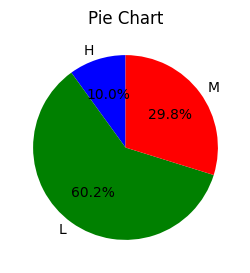

In [94]:
plt.figure(figsize=(3, 3))
plt.pie(Type_counts, labels=Type_counts.index, autopct='%1.1f%%', startangle=90, colors=['blue', 'green', 'red'])
plt.title('Pie Chart')
plt.show()

##### 1. Why did you pick the specific chart?
##### 2. What is/are the insight(s) found from the chart?
##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We can determine the availability of High, Medium, and Low-type products. Notably, 69.7% of the products fall under the low-type category. This insight can have a positive impact, as it provides a clear understanding that most machines in Tata Steel are of lower quality. Therefore, a systematic analysis is essential to ensure an uninterrupted workflow.


#### Chart - 2

In [95]:
toolwearfailure_counts = df['Tool Wear Failure'].value_counts().reset_index()

In [96]:
toolwearfailure_counts

,Tool Wear Failure,count
0,0,90820
1,1,134


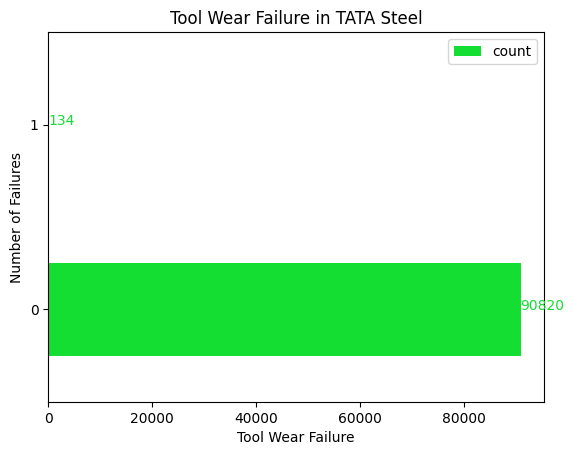

In [97]:
ax= toolwearfailure_counts.plot(x='Tool Wear Failure', y='count', kind='barh', title='Tool Wear Failure	', color=['#14de32'])
ax.set_xlabel('Tool Wear Failure')
ax.set_ylabel('Number of Failures')
ax.set_title('Tool Wear Failure in TATA Steel')

for i, v in enumerate(toolwearfailure_counts['count']):
    ax.text(v+3, i, str(v), color='#14de32')

plt.show()

##### 1. Why did you pick the specific chart?
##### 2. What is/are the insight(s) found from the chart?
##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.




This chart is useful for analyzing the number of machines affected by Tool Wear Failure. It indicates that 134 machines have experienced this issue. This insight is valuable as it confirms that most machines in Tata Steel do not have Tool Wear Failure, offering a clearer perspective on overall machine performance.

#### Chart - 3

In [98]:
# Chart - 3
#Heat Dissipation Failure

In [99]:
heatdissipationfailure_counts = df['Heat Dissipation Failure'].value_counts().reset_index()

In [100]:
heatdissipationfailure_counts


,Heat Dissipation Failure,count
0,0,90468
1,1,486


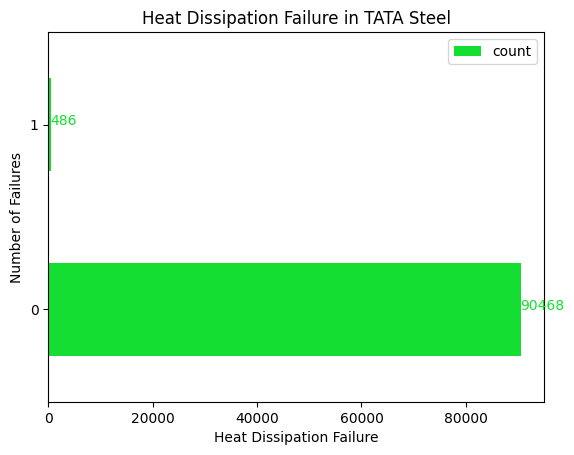

In [101]:
ax= heatdissipationfailure_counts.plot(x='Heat Dissipation Failure', y='count', kind='barh', title='Heat Dissipation Failure	', color=['#14de32'])
ax.set_xlabel('Heat Dissipation Failure')
ax.set_ylabel('Number of Failures')
ax.set_title('Heat Dissipation Failure in TATA Steel')

for i, v in enumerate(heatdissipationfailure_counts['count']):
    ax.text(v+3, i, str(v), color='#14de32')

plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps to compare the number of machine failed. *italicised text*

##### 2. What is/are the insight(s) found from the chart?

It indicates that 486 machines have experienced Heat Dissipation Failure issue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is valuable as it confirms that most machines in Tata Steel do not have Heat Dissipation Failure *issue*, offering a clearer perspective on overall machine performance.

#### Chart - 4

In [102]:
# Chart - 4 visualization code
#Power Failure

In [103]:
powerfailure_counts = df['Power Failure'].value_counts().reset_index()

In [104]:
powerfailure_counts

,Power Failure,count
0,0,90740
1,1,214


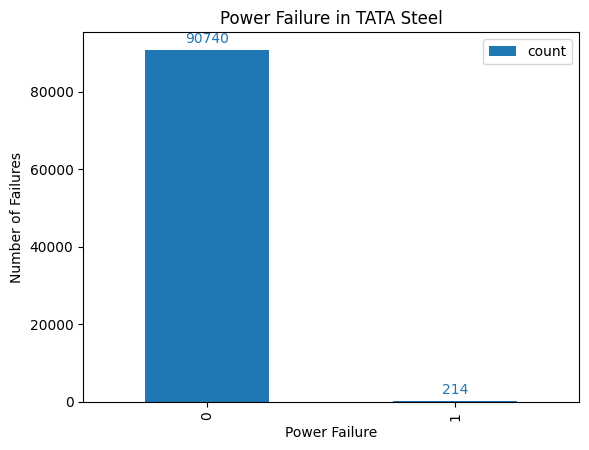

In [105]:
ax = powerfailure_counts.plot(x='Power Failure', y='count', kind='bar', color=['#1f77b4'])
ax.set_xlabel('Power Failure')
ax.set_ylabel('Number of Failures')
ax.set_title('Power Failure in TATA Steel')

for i, v in enumerate(powerfailure_counts['count']):
    ax.text(i, v + max(powerfailure_counts['count']) * 0.02, str(v), ha='center', color='#1f77b4')

plt.show()

##### 1. Why did you pick the specific chart?

A column chart is useful for comparing the number of power failures, as it visually represents variations in failure counts across different machine.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that 214 machines have encountered Power Failure issues, providing a clear visualization of the extent of the problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Th confirms that the majority of machines in Tata Steel are not experiencing Power Failure issues, providing a clearer understanding of overall machine performance.

#### Chart - 5

In [106]:
# Chart - 5 visualization code
#Overstrain Failure

In [107]:
overstrainfailure_counts = df['Overstrain Failure'].value_counts().reset_index()

In [108]:
overstrainfailure_counts

,Overstrain Failure,count
0,0,90602
1,1,352


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


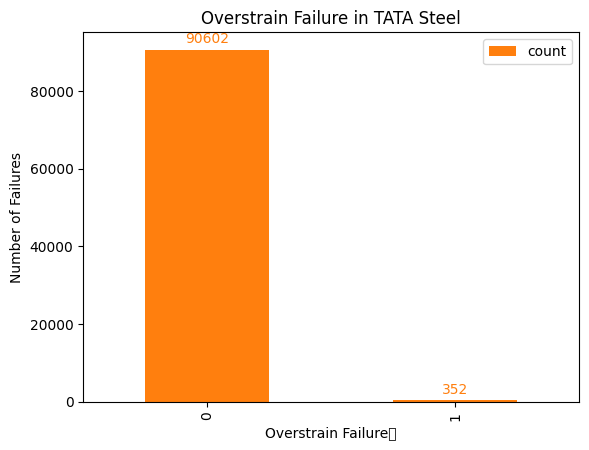

In [109]:
ax = overstrainfailure_counts.plot(x='Overstrain Failure', y='count', kind='bar', color=['#ff7f0e'])
ax.set_xlabel('Overstrain Failure	')
ax.set_ylabel('Number of Failures')
ax.set_title('Overstrain Failure in TATA Steel')

for i, v in enumerate(overstrainfailure_counts['count']):
    ax.text(i, v + max(overstrainfailure_counts['count']) * 0.02, str(v), ha='center', color='#ff7f0e')

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps in comparing the number of Overstrain Failures, as it visually represents variations in failure counts across different machine.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that 352 machines have encountered Overstrain Failure issues, providing a clear visualization of the extent of the problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This confirms that the majority of machines in Tata Steel are not experiencing Overstrain Failure issues, providing a clearer understanding of overall machine performance.

#### Chart - 6

In [110]:
# Chart - 6 visualization code
#Random Failures

In [111]:
randomfailures_counts = df['Random Failures'].value_counts().reset_index()

In [112]:
randomfailures_counts

,Random Failures,count
0,0,90744
1,1,210


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


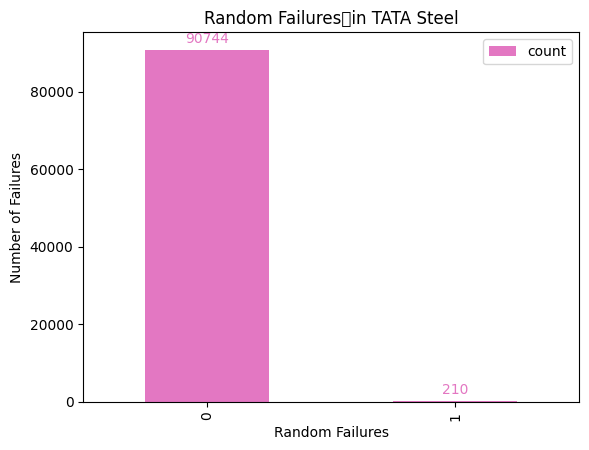

In [113]:
ax = randomfailures_counts.plot(x='Random Failures', y='count', kind='bar', color=['#e377c2'])
ax.set_xlabel('Random Failures')
ax.set_ylabel('Number of Failures')
ax.set_title('Random Failures	in TATA Steel')

for i, v in enumerate(randomfailures_counts['count']):
    ax.text(i, v + max(randomfailures_counts['count']) * 0.02, str(v), ha='center', color='#e377c2')

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps in comparing the number of Random Failures, as it visually represents variations in failure counts across different machine.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that 210 machines have encountered Random Failure issues, providing a clear visualization of the extent of the problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This confirms that the majority of machines in Tata Steel are not experiencing Random Failure issues, providing a clearer understanding of overall machine performance.

#### Chart - 7

In [114]:
# Chart - 7 visualization code
#Air temperature [K]

In [115]:
type_counts = df['Type'].value_counts().reset_index()

In [116]:
type_counts

,Type,count
0,L,63438
1,M,21535
2,H,5981


In [117]:
totalfailures_counts

,Total Failures,count
0,0,89644
1,1,1310


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


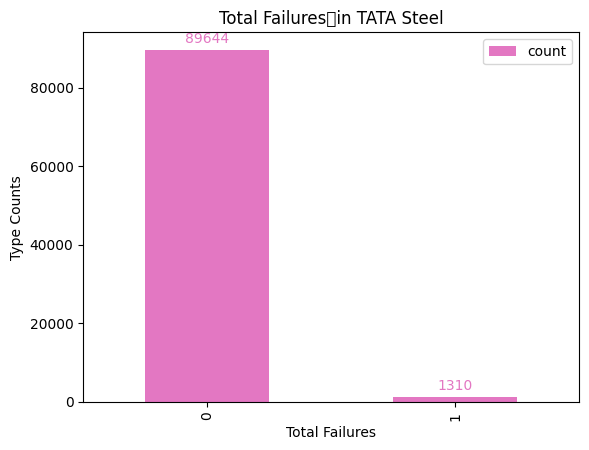

In [118]:
ax = totalfailures_counts.plot(x='Total Failures', y='count', kind='bar', color='#e377c2')
ax.set_xlabel('Total Failures')
ax.set_ylabel('Type Counts')
ax.set_title('Total Failures	in TATA Steel')

for i, v in enumerate(totalfailures_counts['count']):
    ax.text(i, v + max(totalfailures_counts['count']) * 0.02, str(v), ha='center', color='#e377c2')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [119]:
# Chart - 8 visualization code

In [120]:
df_failed = df[df['Total Failures'] == 1]

In [121]:
df_typefailed= df_failed['Type'].value_counts().reset_index()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


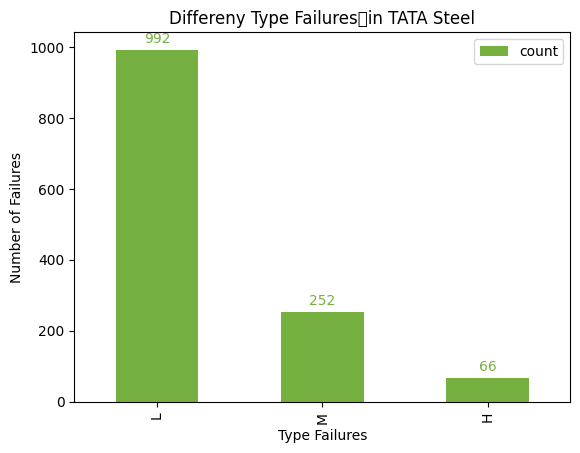

In [122]:
ax = df_typefailed.plot(x='Type', y='count', kind='bar', color='#76b041')
ax.set_xlabel('Type Failures')
ax.set_ylabel('Number of Failures')
ax.set_title('Differeny Type Failures	in TATA Steel')

for i, v in enumerate(df_typefailed['count']):
    ax.text(i, v + max(df_typefailed['count']) * 0.02, str(v), ha='center', color='#76b041')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [123]:
# Chart - 9 visualization code

In [124]:
df_heatdissipationfailure=df[df['Heat Dissipation Failure'] == 1]

In [125]:
df_heatdissipationfailure

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures,Total Failures,Air Process Temperature Difference
223,136652,L51575,L,302.2,310.1,1359,50.4,22,0,1,0,0,0,1,-7.9
397,136826,H33908,H,302.6,310.4,1382,56.5,85,0,1,0,0,0,1,-7.8
531,136960,L51904,L,303.4,311.9,1366,50.9,202,0,1,0,0,0,1,-8.5
608,137037,L51935,L,303.4,311.7,1295,51.3,155,0,1,0,0,0,1,-8.3
683,137112,L52042,L,303.5,312.0,1384,44.0,114,0,1,0,0,0,1,-8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89462,225891,L51652,L,302.7,310.6,1365,48.7,4,0,1,0,0,0,1,-7.9
89662,226091,L52163,L,303.7,313.0,1375,55.7,209,0,1,0,0,0,1,-9.3
89949,226378,M19019,M,301.9,310.4,1340,48.0,37,0,1,0,0,0,1,-8.5
90503,226932,H33815,H,302.2,310.1,1339,51.1,12,0,1,0,0,0,1,-7.9


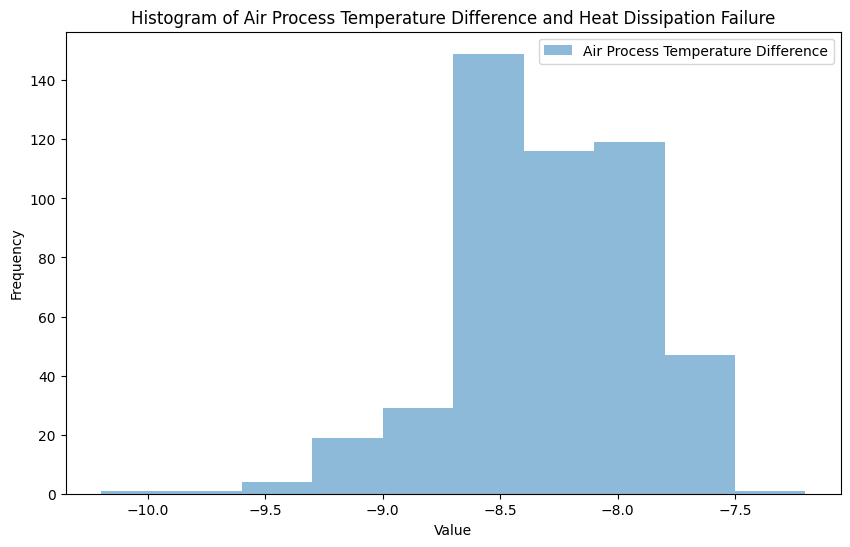

In [126]:
plt.figure(figsize=(10, 6))

plt.hist(df_heatdissipationfailure['Air Process Temperature Difference'], bins=10, alpha=0.5, label='Air Process Temperature Difference', color='#1f77b4')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Air Process Temperature Difference and Heat Dissipation Failure')


plt.legend()


plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [127]:
# Chart - 10 visualization code

In [128]:
df_toolwearfailure=df[df['Tool Wear Failure'] == 1]

In [129]:
df_toolwearfailure

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failures,Total Failures,Air Process Temperature Difference
1787,138216,L55458,L,298.8,310.5,1464,46.4,207,1,0,0,0,0,1,-11.7
2632,139061,M17793,M,300.6,309.6,1435,52.2,215,1,0,0,0,0,1,-9.0
3195,139624,L48276,L,297.0,307.6,1680,30.5,220,1,0,0,0,0,1,-10.6
3297,139726,L48776,L,298.0,308.1,1877,35.0,218,1,0,0,0,0,1,-10.1
3417,139846,L55379,L,299.3,310.8,1431,41.2,225,1,0,0,0,0,1,-11.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88577,225006,M18666,M,302.3,311.0,1510,42.4,204,1,0,0,0,1,1,-8.7
88830,225259,L57010,L,298.4,309.3,1397,49.4,206,1,0,0,0,0,1,-10.9
88892,225321,M20859,M,300.8,310.2,1671,30.5,234,1,0,0,0,0,1,-9.4
89049,225478,L52288,L,303.9,313.2,1367,54.0,182,1,0,0,0,0,1,-9.3


In [130]:
df_average_tool_wear = df_toolwearfailure.groupby('Type')['Tool wear [min]'].mean().reset_index()

print(df_average_tool_wear)


  Type  Tool wear [min]
0    H       153.000000
1    L       172.340426
2    M       192.781250


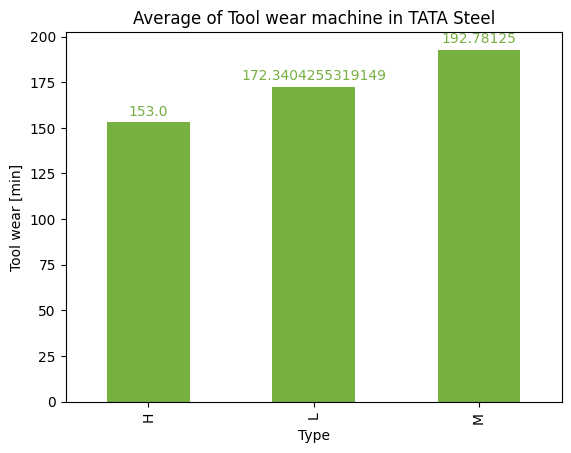

In [131]:
ax = df_average_tool_wear.plot(x='Type', y='Tool wear [min]', kind='bar', color='#76b041', legend=False)

ax.set_xlabel('Type')
ax.set_ylabel('Tool wear [min]')
ax.set_title('Average of Tool wear machine in TATA Steel')

for i, v in enumerate(df_average_tool_wear['Tool wear [min]']):
    ax.text(i, v + max(df_average_tool_wear['Tool wear [min]']) * 0.02, str(v), ha='center', color='#76b041')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [132]:
# Chart - 11 visualization code

In [133]:
df_toolwearfailure_product = df.groupby('Product ID')['Tool Wear Failure'].sum(). sort_values(ascending=False).reset_index()

In [134]:
df_toolwearfailure_product

,Product ID,Tool Wear Failure
0,L53352,5
1,L51214,4
2,L55379,3
3,L54690,3
4,M17531,3
...,...,...
9904,L51092,0
9905,L51094,0
9906,L51095,0
9907,L51096,0


In [135]:
top_10_toolwearfailure=df_toolwearfailure_product.head(10)

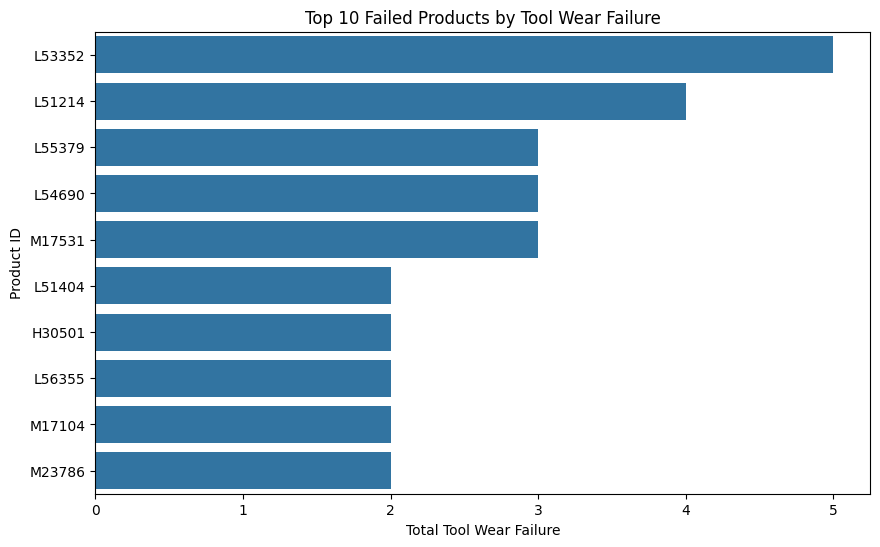

In [136]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Tool Wear Failure', y='Product ID', data=top_10_toolwearfailure)

plt.xlabel('Total Tool Wear Failure')
plt.ylabel('Product ID')
plt.title('Top 10 Failed Products by Tool Wear Failure')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [137]:
# Chart - 12 visualization code

In [138]:
df_heatdissipationfailure_product = df.groupby('Product ID')['Heat Dissipation Failure'].sum(). sort_values(ascending=False).reset_index()

In [139]:
top_10_heatdissipationfailure=df_heatdissipationfailure_product.head(10)

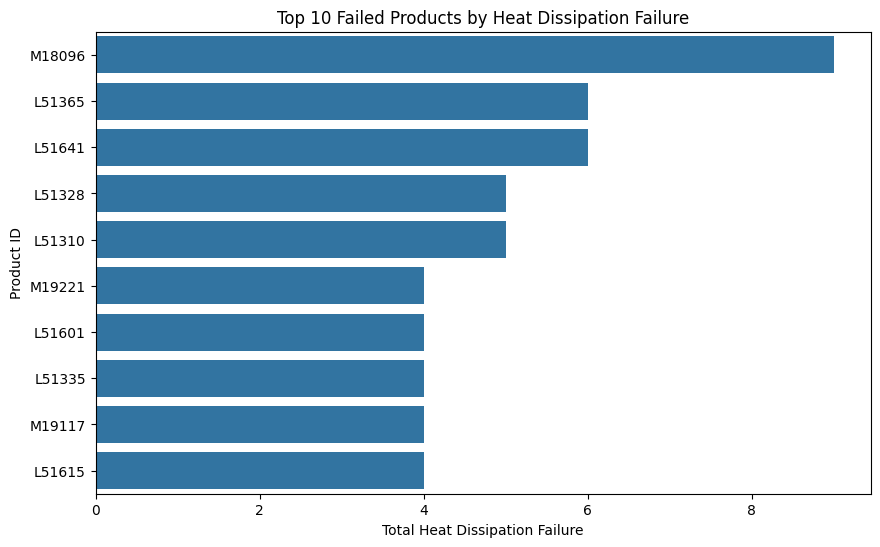

In [140]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Heat Dissipation Failure', y='Product ID', data=top_10_heatdissipationfailure)

plt.xlabel('Total Heat Dissipation Failure')
plt.ylabel('Product ID')
plt.title('Top 10 Failed Products by Heat Dissipation Failure')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [141]:
# Chart - 13 visualization code

In [142]:
df_powerfailure_product = df.groupby('Product ID')['Power Failure'].sum(). sort_values(ascending=False).reset_index()

In [143]:
top_10_powerfailure=df_powerfailure_product.head(10)

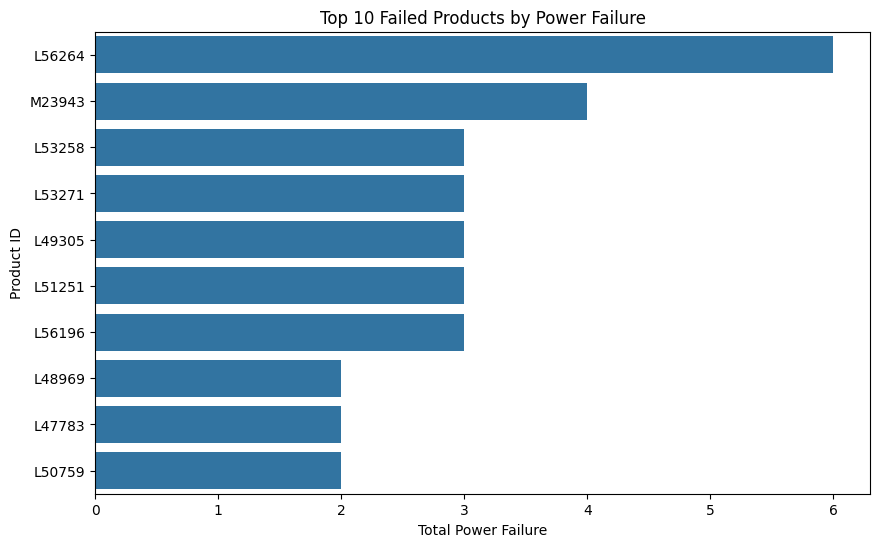

In [144]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Power Failure', y='Product ID', data=top_10_powerfailure)

plt.xlabel('Total Power Failure')
plt.ylabel('Product ID')
plt.title('Top 10 Failed Products by Power Failure')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

In [150]:
df_torque_filtered = df[df['Torque [Nm]'] > 50][[]]

In [152]:
correlation_matrix = df_torque_filtered.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap (Torque [Nm] > 50)')

plt.show()

ValueError: could not convert string to float: 'L52914'

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [154]:
# Pair Plot visualization code

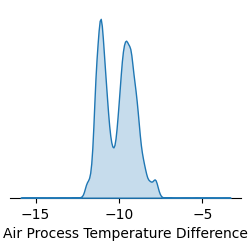

In [157]:
selected_columns = ['Air Process Temperature Difference']

sns.pairplot(df[selected_columns], diag_kind='kde', corner=True)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

# **Conclusion**

Write the conclusion here.